Setup

In [ ]:
"""
Week 1: Advertiser Funnel Analysis
Exploratory analysis and visualizations
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('../shared-sql')
from db_config import get_engine

# Styling
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10



✅ Setup complete!
Pandas version: 2.1.0
Matplotlib version: 3.7.2


 Load Data from Database

In [2]:
# Connect to database
engine = get_engine()

# Load funnel data from views
funnel_accounts = pd.read_sql("SELECT * FROM vw_account_funnel", engine)
funnel_summary = pd.read_sql("SELECT * FROM vw_funnel_summary", engine)
product_perf = pd.read_sql("SELECT * FROM vw_product_performance", engine)

print(f"\nData loaded successfully!")
print(f"Accounts: {len(funnel_accounts):,}")
print(f"Funnel summaries: {len(funnel_summary):,}")
print(f"Product performance records: {len(product_perf):,}")

# Display first few rows
print("\nSample of account funnel data:")
funnel_accounts.head()


Data loaded successfully!
Accounts: 850
Funnel summaries: 12
Product performance records: 9

Sample of account funnel data:


,account_id,account_name,segment,region,signup_date,account_status,stage_signup,stage_campaign_created,stage_had_impressions,stage_had_clicks,stage_had_conversions,total_impressions,total_clicks,total_conversions,total_spend,ctr_percent,cvr_percent
0,ACC000166,Advertiser_166,SMB,North America,2025-06-03,Active,1,0,0,0,0,0,0,0,0.0,0.0,0.0
1,ACC000205,Advertiser_205,SMB,EMEA,2025-04-27,Active,1,0,0,0,0,0,0,0,0.0,0.0,0.0
2,ACC000180,Advertiser_180,SMB,APAC,2025-11-16,Active,1,0,0,0,0,0,0,0,0.0,0.0,0.0
3,ACC000406,Advertiser_406,SMB,North America,2025-04-15,Active,1,0,0,0,0,0,0,0,0.0,0.0,0.0
4,ACC000801,Advertiser_801,Mid-Market,EMEA,2025-12-08,Active,1,0,0,0,0,0,0,0,0.0,0.0,0.0


Overall Funnel Visualization

Creating Overall Funnel Visualization...



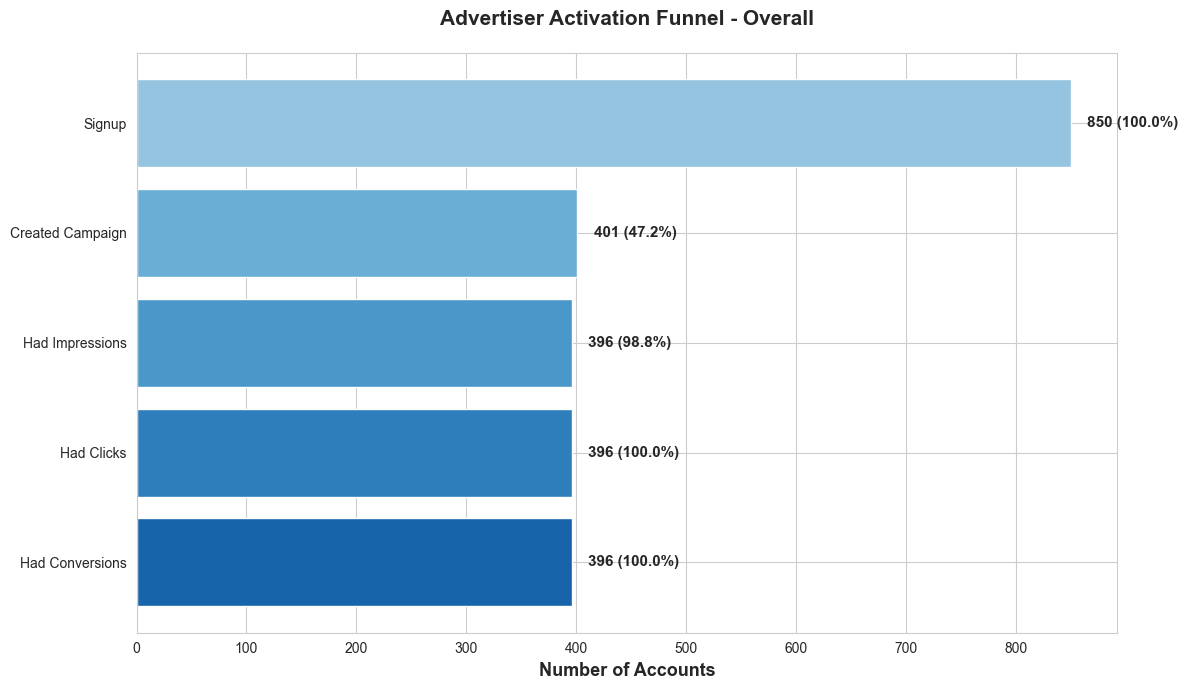


Funnel Summary:
   Signup: 850
   Created Campaign: 401
   Had Impressions: 396
   Had Clicks: 396
   Had Conversions: 396


In [3]:
# Calculate overall funnel stages
print("Creating Overall Funnel Visualization...\n")

funnel_stages = {
    'Signup': funnel_accounts['stage_signup'].sum(),
    'Created Campaign': funnel_accounts['stage_campaign_created'].sum(),
    'Had Impressions': funnel_accounts['stage_had_impressions'].sum(),
    'Had Clicks': funnel_accounts['stage_had_clicks'].sum(),
    'Had Conversions': funnel_accounts['stage_had_conversions'].sum()
}

# Calculate conversion rates
stages = list(funnel_stages.keys())
values = list(funnel_stages.values())

conv_rates = [100]  # Start at 100%
for i in range(1, len(values)):
    rate = (values[i] / values[i-1]) * 100
    conv_rates.append(rate)

# Create funnel chart
fig, ax = plt.subplots(figsize=(12, 7))

colors = plt.cm.Blues(np.linspace(0.4, 0.8, len(stages)))
bars = ax.barh(stages, values, color=colors)

# Add value labels
for i, (bar, val, rate) in enumerate(zip(bars, values, conv_rates)):
    ax.text(val + 15, bar.get_y() + bar.get_height()/2, 
            f'{val:,} ({rate:.1f}%)', 
            va='center', fontweight='bold', fontsize=11)

ax.set_xlabel('Number of Accounts', fontsize=13, fontweight='bold')
ax.set_title('Advertiser Activation Funnel - Overall', fontsize=15, fontweight='bold', pad=20)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../images/week1_overall_funnel.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nFunnel Summary:")
for stage, val in funnel_stages.items():
    print(f"   {stage}: {val:,}")

Segment Comparison

Creating Segment Comparison...

Segment Funnel Conversion Rates:
      segment  signup_to_campaign_pct  campaign_to_click_pct  \
0  Enterprise                    86.7                   98.7   
1  Mid-Market                    58.1                  100.0   
2         SMB                    37.7                   98.2   

   click_to_conversion_pct  
0                    100.0  
1                    100.0  
2                    100.0  


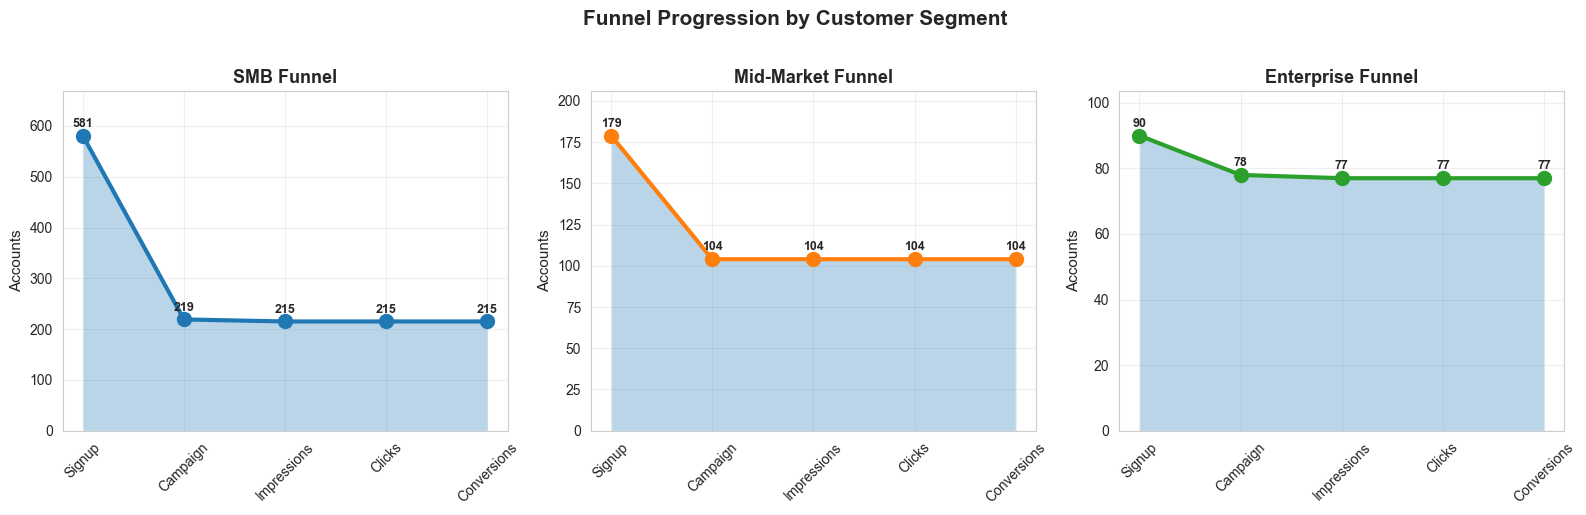

In [4]:
# Funnel by segment
print("Creating Segment Comparison...\n")

segment_funnel = funnel_accounts.groupby('segment').agg({
    'stage_signup': 'sum',
    'stage_campaign_created': 'sum',
    'stage_had_impressions': 'sum',
    'stage_had_clicks': 'sum',
    'stage_had_conversions': 'sum'
}).reset_index()

# Calculate conversion rates
segment_funnel['signup_to_campaign_pct'] = (segment_funnel['stage_campaign_created'] / segment_funnel['stage_signup'] * 100).round(1)
segment_funnel['campaign_to_click_pct'] = (segment_funnel['stage_had_clicks'] / segment_funnel['stage_campaign_created'] * 100).round(1)
segment_funnel['click_to_conversion_pct'] = (segment_funnel['stage_had_conversions'] / segment_funnel['stage_had_clicks'] * 100).round(1)

print("Segment Funnel Conversion Rates:")
print(segment_funnel[['segment', 'signup_to_campaign_pct', 'campaign_to_click_pct', 'click_to_conversion_pct']])

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, segment in enumerate(['SMB', 'Mid-Market', 'Enterprise']):
    if segment not in segment_funnel['segment'].values:
        continue
        
    seg_data = segment_funnel[segment_funnel['segment'] == segment].iloc[0]
    
    stages = ['Signup', 'Campaign', 'Impressions', 'Clicks', 'Conversions']
    values = [
        seg_data['stage_signup'],
        seg_data['stage_campaign_created'],
        seg_data['stage_had_impressions'],
        seg_data['stage_had_clicks'],
        seg_data['stage_had_conversions']
    ]
    
    axes[idx].plot(stages, values, marker='o', linewidth=3, markersize=10, color=['#1f77b4', '#ff7f0e', '#2ca02c'][idx])
    axes[idx].fill_between(range(len(stages)), values, alpha=0.3)
    axes[idx].set_title(f'{segment} Funnel', fontweight='bold', fontsize=13)
    axes[idx].set_ylabel('Accounts', fontsize=11)
    axes[idx].set_ylim(0, max(values) * 1.15)
    axes[idx].grid(alpha=0.3)
    axes[idx].tick_params(axis='x', rotation=45)
    
    # Add value labels
    for i, val in enumerate(values):
        axes[idx].text(i, val + max(values)*0.03, f'{int(val):,}', 
                      ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Funnel Progression by Customer Segment', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../images/week1_segment_funnels.png', dpi=300, bbox_inches='tight')
plt.show()

Drop-off Analysis

Analyzing Funnel Drop-offs...

Drop-off Analysis:
      Stage Transition  Accounts Lost  Pct_of_Original
     Signup → Campaign            449             52.8
Campaign → Impressions              5              0.6
  Impressions → Clicks              0              0.0
  Clicks → Conversions              0              0.0


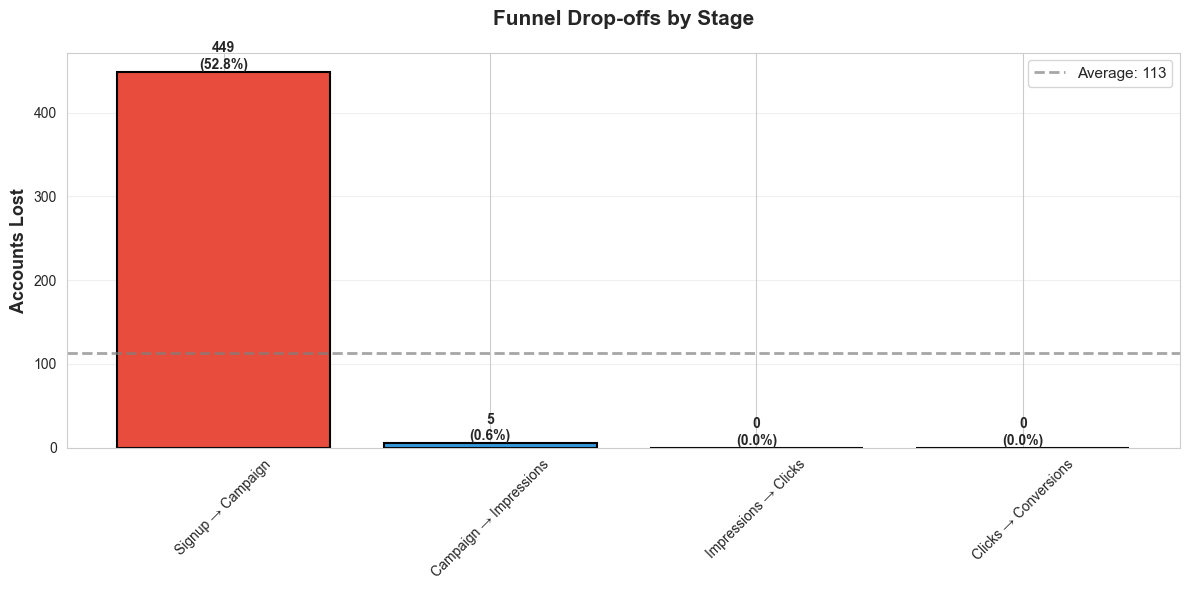


BIGGEST LEAK: Signup → Campaign
   → 449 accounts lost (52.8% of signups)


In [5]:
# Calculate drop-offs at each stage
print("Analyzing Funnel Drop-offs...\n")

overall_dropoffs = pd.DataFrame({
    'Stage Transition': [
        'Signup → Campaign',
        'Campaign → Impressions',
        'Impressions → Clicks',
        'Clicks → Conversions'
    ],
    'Accounts Lost': [
        funnel_stages['Signup'] - funnel_stages['Created Campaign'],
        funnel_stages['Created Campaign'] - funnel_stages['Had Impressions'],
        funnel_stages['Had Impressions'] - funnel_stages['Had Clicks'],
        funnel_stages['Had Clicks'] - funnel_stages['Had Conversions']
    ]
})

overall_dropoffs['Pct_of_Original'] = (overall_dropoffs['Accounts Lost'] / funnel_stages['Signup'] * 100).round(1)

print("Drop-off Analysis:")
print(overall_dropoffs.to_string(index=False))

# Visualization
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#e74c3c' if x > overall_dropoffs['Accounts Lost'].mean() else '#3498db' 
          for x in overall_dropoffs['Accounts Lost']]
bars = ax.bar(overall_dropoffs['Stage Transition'], overall_dropoffs['Accounts Lost'], color=colors, edgecolor='black', linewidth=1.5)

ax.set_ylabel('Accounts Lost', fontsize=13, fontweight='bold')
ax.set_title('Funnel Drop-offs by Stage', fontsize=15, fontweight='bold', pad=20)
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)

# Add value labels
for bar, val, pct in zip(bars, overall_dropoffs['Accounts Lost'], overall_dropoffs['Pct_of_Original']):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(val):,}\n({pct:.1f}%)',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

# Add average line
avg = overall_dropoffs['Accounts Lost'].mean()
ax.axhline(y=avg, color='gray', linestyle='--', linewidth=2, alpha=0.7, label=f'Average: {int(avg):,}')
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('../images/week1_dropoffs.png', dpi=300, bbox_inches='tight')
plt.show()

# Identify biggest leak
biggest_leak = overall_dropoffs.loc[overall_dropoffs['Accounts Lost'].idxmax()]
print(f"\nBIGGEST LEAK: {biggest_leak['Stage Transition']}")
print(f"   → {int(biggest_leak['Accounts Lost']):,} accounts lost ({biggest_leak['Pct_of_Original']:.1f}% of signups)")

Product Performance Heatmap

Analyzing Product Type Performance...



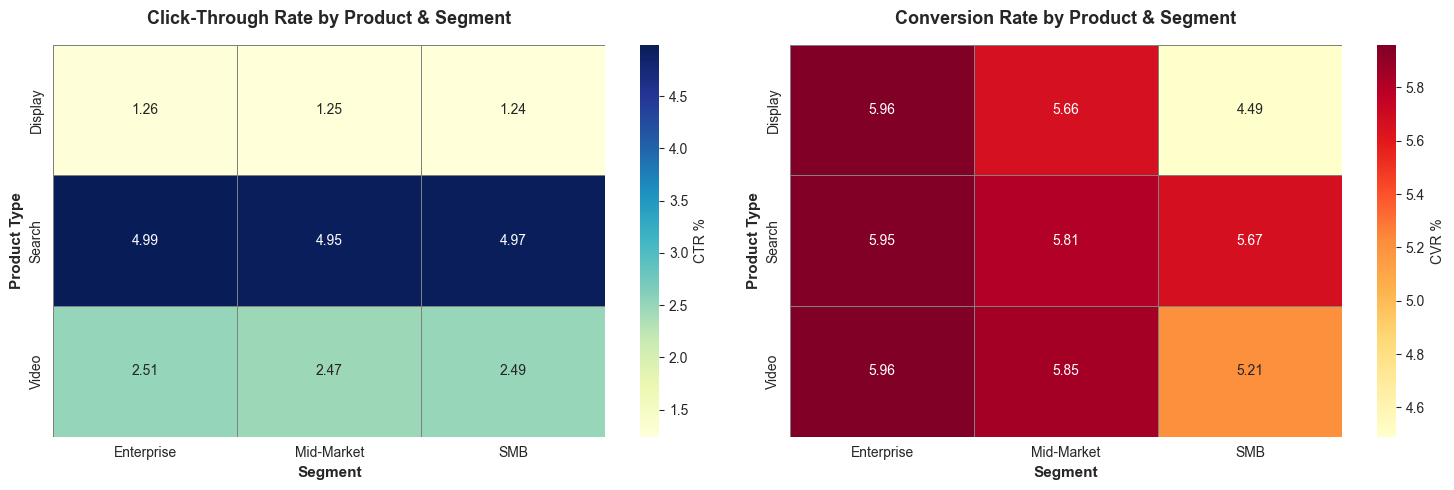


Product Performance Summary:
              ctr_percent  cvr_percent   cpc
product_type                                
Display              1.25         5.37  0.99
Search               4.97         5.81  2.75
Video                2.49         5.67  1.39

Best CTR: Search (Enterprise) - 4.99%
Best CVR: Display (Enterprise) - 5.96%


In [6]:
# Product performance analysis
print("Analyzing Product Type Performance...\n")

# Create pivot tables for heatmaps
ctr_pivot = product_perf.pivot_table(
    index='product_type',
    columns='segment',
    values='ctr_percent',
    aggfunc='mean'
)

cvr_pivot = product_perf.pivot_table(
    index='product_type',
    columns='segment',
    values='cvr_percent',
    aggfunc='mean'
)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Heatmap 1: CTR
sns.heatmap(ctr_pivot, annot=True, fmt='.2f', cmap='YlGnBu', ax=axes[0], 
            cbar_kws={'label': 'CTR %'}, linewidths=0.5, linecolor='gray')
axes[0].set_title('Click-Through Rate by Product & Segment', fontweight='bold', fontsize=13, pad=15)
axes[0].set_xlabel('Segment', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Product Type', fontsize=11, fontweight='bold')

# Heatmap 2: CVR
sns.heatmap(cvr_pivot, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[1], 
            cbar_kws={'label': 'CVR %'}, linewidths=0.5, linecolor='gray')
axes[1].set_title('Conversion Rate by Product & Segment', fontweight='bold', fontsize=13, pad=15)
axes[1].set_xlabel('Segment', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Product Type', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../images/week1_product_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# Summary statistics
print("\nProduct Performance Summary:")
product_summary = product_perf.groupby('product_type')[['ctr_percent', 'cvr_percent', 'cpc']].mean()
print(product_summary.round(2))

# Best performing product
best_ctr = product_perf.loc[product_perf['ctr_percent'].idxmax()]
print(f"\nBest CTR: {best_ctr['product_type']} ({best_ctr['segment']}) - {best_ctr['ctr_percent']:.2f}%")

best_cvr = product_perf.loc[product_perf['cvr_percent'].idxmax()]
print(f"Best CVR: {best_cvr['product_type']} ({best_cvr['segment']}) - {best_cvr['cvr_percent']:.2f}%")

Key Insights Summary

In [7]:
# Generate key insights
print("="*70)
print("KEY INSIGHTS - WEEK 1 FUNNEL ANALYSIS")
print("="*70)

# Insight 1: Biggest drop-off
max_dropoff = overall_dropoffs.loc[overall_dropoffs['Accounts Lost'].idxmax()]
print(f"\n1. BIGGEST LEAK: {max_dropoff['Stage Transition']}")
print(f"{int(max_dropoff['Accounts Lost']):,} accounts lost ({max_dropoff['Pct_of_Original']:.1f}% of signups)")
print(f"Recommendation: Investigate barriers in this transition")

# Insight 2: Segment performance gap
segment_conversion = funnel_summary.groupby('segment')['overall_conversion_pct'].mean()
if len(segment_conversion) > 0:
    best_segment = segment_conversion.idxmax()
    worst_segment = segment_conversion.idxmin()
    gap = segment_conversion[best_segment] - segment_conversion[worst_segment]
    
    print(f"\n2. SEGMENT GAP: {best_segment} outperforms {worst_segment} by {gap:.1f} percentage points")
    print(f"{best_segment}: {segment_conversion[best_segment]:.1f}% overall conversion")
    print(f"{worst_segment}: {segment_conversion[worst_segment]:.1f}% overall conversion")
    print(f"Recommendation: Improve onboarding for {worst_segment} segment")

# Insight 3: Product type performance
product_avg_ctr = product_perf.groupby('product_type')['ctr_percent'].mean()
if len(product_avg_ctr) > 0:
    best_product = product_avg_ctr.idxmax()
    worst_product = product_avg_ctr.idxmin()
    
    print(f"\n3. PRODUCT PERFORMANCE: {best_product} campaigns show highest engagement")
    print(f"{best_product} CTR: {product_avg_ctr[best_product]:.2f}%")
    print(f"{worst_product} CTR: {product_avg_ctr[worst_product]:.2f}%")
    print(f"Recommendation: Promote {best_product} product earlier in onboarding")

# Insight 4: Activation rate
total_signups = funnel_accounts['stage_signup'].sum()
activated = funnel_accounts['stage_campaign_created'].sum()
activation_rate = (activated / total_signups) * 100

print(f"\n4. ACTIVATION RATE: {activation_rate:.1f}% of signups create campaigns")
benchmark = 70
if activation_rate < benchmark:
    print(f"Below industry benchmark ({benchmark}%)")
    print(f"Recommendation: Simplify campaign creation flow")
else:
    print(f"Above industry benchmark ({benchmark}%)")

# Insight 5: Total business metrics
total_spend = funnel_accounts['total_spend'].sum()
total_conversions = funnel_accounts['total_conversions'].sum()
avg_ctr = funnel_accounts[funnel_accounts['ctr_percent'] > 0]['ctr_percent'].mean()

print(f"\n5. BUSINESS METRICS:")
print(f"Total Ad Spend: ${total_spend:,.2f}")
print(f"Total Conversions: {int(total_conversions):,}")
print(f"Average CTR: {avg_ctr:.2f}%")

print("\n" + "="*70)
print("ANALYSIS COMPLETE - Insights ready for presentation")
print("="*70)

KEY INSIGHTS - WEEK 1 FUNNEL ANALYSIS

1. BIGGEST LEAK: Signup → Campaign
449 accounts lost (52.8% of signups)
Recommendation: Investigate barriers in this transition

2. SEGMENT GAP: Enterprise outperforms SMB by 47.6 percentage points
Enterprise: 86.9% overall conversion
SMB: 39.3% overall conversion
Recommendation: Improve onboarding for SMB segment

3. PRODUCT PERFORMANCE: Search campaigns show highest engagement
Search CTR: 4.97%
Display CTR: 1.25%
Recommendation: Promote Search product earlier in onboarding

4. ACTIVATION RATE: 47.2% of signups create campaigns
Below industry benchmark (70%)
Recommendation: Simplify campaign creation flow

5. BUSINESS METRICS:
Total Ad Spend: $49,664,021.74
Total Conversions: 1,454,386
Average CTR: 2.91%

ANALYSIS COMPLETE - Insights ready for presentation


Save Summary & Export

In [9]:
# Create insights summary file
print("Saving insights summary...\n")

insights_text = f"""
WEEK 1: ADVERTISER FUNNEL DIAGNOSTICS - KEY FINDINGS
{'='*70}

Generated: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M')}

DATASET OVERVIEW:
- Total Accounts: {len(funnel_accounts):,}
- Total Campaigns: {len(product_perf):,}
- Total Ad Spend: ${funnel_accounts['total_spend'].sum():,.2f}
- Date Range: Last 90 days

KEY INSIGHTS:

1. BIGGEST FUNNEL LEAK
   Stage: {max_dropoff['Stage Transition']}
   Accounts Lost: {int(max_dropoff['Accounts Lost']):,} ({max_dropoff['Pct_of_Original']:.1f}% of signups)
   
2. SEGMENT PERFORMANCE
   Best: {best_segment} ({segment_conversion[best_segment]:.1f}% conversion)
   Worst: {worst_segment} ({segment_conversion[worst_segment]:.1f}% conversion)
   Gap: {gap:.1f} percentage points
   
3. PRODUCT ENGAGEMENT
   Best CTR: {best_product} ({product_avg_ctr[best_product]:.2f}%)
   Worst CTR: {worst_product} ({product_avg_ctr[worst_product]:.2f}%)
   
4. ACTIVATION METRICS
   Rate: {activation_rate:.1f}%
   Status: {'Below' if activation_rate < 70 else 'Above'} benchmark (70%)

BUSINESS RECOMMENDATIONS:

1. Improve {max_dropoff['Stage Transition']} transition
   - Simplify user experience at this stage
   - Add in-app guidance and templates
   
2. Segment-specific onboarding
   - {worst_segment}: Focus on activation improvements
   - {best_segment}: Study best practices to replicate
   
3. Product promotion
   - Highlight {best_product} product benefits earlier
   - Improve {worst_product} campaign setup flow

VISUALIZATIONS CREATED:
- Overall funnel chart (week1_overall_funnel.png)
- Segment comparison (week1_segment_funnels.png)
- Drop-off analysis (week1_dropoffs.png)
- Product performance heatmap (week1_product_heatmap.png)

{'='*70}
"""

# Save to file with UTF-8 encoding
with open('week1_insights_summary.txt', 'w', encoding='utf-8') as f:
    f.write(insights_text)

print("Insights summary saved to: week1_insights_summary.txt")

# List all created visualizations
import os
image_files = [f for f in os.listdir('../images') if f.startswith('week1_')]
print(f"\nVisualizations created ({len(image_files)}):")
for img in sorted(image_files):
    print(f"{img}")



Saving insights summary...

Insights summary saved to: week1_insights_summary.txt

Visualizations created (4):
week1_dropoffs.png
week1_overall_funnel.png
week1_product_heatmap.png
week1_segment_funnels.png
